# Direct Debit Propensity Prediction – Allianz Insurance

## Business Context

**Allianz** is a multinational financial services group offering life, health, and non-life insurance products, as well as asset management, to 88M+ clients across 70+ countries.

**The problem:** Only **21% of Allianz insurance contracts** use direct debit as a payment method, compared to an industry average of **65%**. This gap has direct consequences for the business:

- Reduced working capital efficiency
- Less predictable cash flow
- Higher administrative overhead from manual payment follow-up

**The objective:** Build a machine learning model that predicts which policyholders are likely to adopt direct debit, enabling targeted outreach and improving the direct debit adoption rate across the existing portfolio.

**Business questions answered:**
- What client and contract characteristics are most predictive of direct debit adoption?
- Can we reliably classify propensity using available contract-level data?
- Does removing product-level variables (premium, product type) change which factors drive the prediction?

---

**Framework:** CRISP-DM (Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation)

**Stack:** Python · Scikit-learn · Pandas · NumPy · Matplotlib · Seaborn

**Data:** 452,220 Allianz insurance contracts (14 variables)


## Imports

- `pandas` / `numpy` — data manipulation
- `seaborn` / `matplotlib` — visualization
- `sklearn.preprocessing` — label encoding
- `sklearn.utils.resample` — class balancing (upsampling)
- `sklearn` models — Logistic Regression, Decision Tree, Random Forest
- `sklearn.metrics` — F1, Precision, Recall, Log Loss, Confusion Matrix


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

# Procesamiento y resample
from sklearn import preprocessing
from sklearn.utils import resample

# Modelos y métricas
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, log_loss, confusion_matrix

# Procesamiento de datos | Clustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Modelos y métricas | Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Data Loading

452,220 insurance contract records are loaded from the dataset. The `nrows` parameter is set explicitly to avoid reading trailing empty rows.


In [5]:
df= pd.read_excel('direct_debit.xlsx', sheet_name=1, nrows= 452220)

In [6]:
df.head()

,Broker_account_number,Contract_number,Customer_segment,Line_of_business,Product_type,Annual_premium,Payment_frequency,Customer_ID,Customer_age,Customer_type,Customer_region,Customer_province,Broker_region,Broker_province,Is_direct_debit,Broker_cor,Customer_urbanization,Broker_urbanization
0,DJEA04015816746062,DJUI09715331435925,Midcorp,I - Property,I05 - BUILDING,2632.45,Annually,8643674,No age,Enterprise,BRU,BRU,BRU,BRU,0,5.619862e+09,Urban,Urban
1,DJEA04015816746062,GJZP42914011343072,Midcorp,I - Property,I05 - BUILDING,4996.78,Annually,8338883,No age,Enterprise,BRU,BRU,BRU,BRU,0,5.619862e+09,Urban,Urban
2,DJEA04015816746062,NXLM98303446560119,Midcorp,I - Property,I05 - BUILDING,1734.62,Annually,8338892,No age,Enterprise,BRU,BRU,BRU,BRU,0,5.619862e+09,Urban,Urban
3,DJEA04015816746062,AITL42127947858417,Midcorp,I - Property,I05 - BUILDING,2460.68,Annually,8338893,No age,Enterprise,BRU,BRU,BRU,BRU,0,5.619862e+09,Urban,Urban
4,UTAY89397600598587,IBPJ05282371448674,Midcorp,D - Property,D01 - RISQ IND,7731.46,Annually,3301814,No age,Enterprise,BRU,BRU,BRU,BRU,0,6.721423e+09,Urban,Urban


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452220 entries, 0 to 452219
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Broker_account_number  452220 non-null  object 
 1   Contract_number        452220 non-null  object 
 2   Customer_segment       452220 non-null  object 
 3   Line_of_business       452220 non-null  object 
 4   Product_type           452220 non-null  object 
 5   Annual_premium         452220 non-null  float64
 6   Payment_frequency      452220 non-null  object 
 7   Customer_ID            452220 non-null  int64  
 8   Customer_age           452220 non-null  object 
 9   Customer_type          452220 non-null  object 
 10  Customer_region        452220 non-null  object 
 11  Customer_province      452220 non-null  object 
 12  Broker_region          452220 non-null  object 
 13  Broker_province        452220 non-null  object 
 14  Is_direct_debit        452220 non-nu

## Data Cleaning & Preparation

The following steps are applied in sequence:

1. **Remove duplicate contracts** — identified by `Contract_number`
2. **Drop broker and payment variables** — `Broker_account_number`, `Broker_province`, `Broker_region`, `Broker_cor`, `Payment_frequency`, `Broker_urbanization` are dropped; `premium` and `ptype` are retained to evaluate their predictive relevance
3. **Drop contract and customer identifiers** — `Contract_number`, `Customer_ID` are non-predictive
4. **Rename columns** for brevity in downstream code
5. **Label encode** all categorical variables
6. **Upsample** the minority class (`y=1`, direct debit users) to balance the dataset
7. **Remove outliers** from `premium` using the IQR method
8. **Train/test split** — 70/30


In [9]:
# Identificación de contratos duplicados
len(df[df.duplicated()])

64

In [10]:
# Ejemplo de un contrato duplicado
df[df.Contract_number == 'JXVD68770534269864']

,Broker_account_number,Contract_number,Customer_segment,Line_of_business,Product_type,Annual_premium,Payment_frequency,Customer_ID,Customer_age,Customer_type,Customer_region,Customer_province,Broker_region,Broker_province,Is_direct_debit,Broker_cor,Customer_urbanization,Broker_urbanization
11797,LZKV19274747919255,JXVD68770534269864,Midcorp,R - Engineering,R07 - RESTART,229.28,Annually,8449749,No age,Enterprise,FLA,VLI,FLA,VLI,0,4.804226e+09,Rural,Rural
11798,LZKV19274747919255,JXVD68770534269864,Midcorp,R - Engineering,R07 - RESTART,229.28,Annually,8449749,No age,Enterprise,FLA,VLI,FLA,VLI,0,4.804226e+09,Rural,Rural


In [11]:
# Eliminación de contratos duplicados y confirmación de limpieza
df.drop_duplicates(inplace=True)
len(df[df.duplicated()])

0

In [12]:
# Eliminación de variables del broker y producto: mantenemos premium y product type para evaluar su relevancia en el modelo
df.drop(['Broker_account_number', 'Broker_province', 'Broker_region', 'Broker_cor', 'Payment_frequency', 'Broker_urbanization'], axis= 1, inplace= True)

In [13]:
# Eliminación de identificadores del contrato y cliente
df.drop(['Contract_number', 'Customer_ID'], axis= 1, inplace= True)

In [14]:
# Renombramiento de columnas
df.rename(columns= {'Customer_segment': 'cs', 'Line_of_business': 'lob', 'Product_type': 'ptype', 'Annual_premium': 'premium', 'Customer_age': 'age', 'Customer_type': 'type', 'Customer_region': 'region', 'Customer_province': 'prov', 'Is_direct_debit': 'y', 'Customer_urbanization': 'urban'}, inplace=True)

# Identificación de variables categóricas
cat= ['cs', 'lob', 'age', 'type', 'region', 'prov', 'urban', 'ptype']

# No se identifican variables numéricas porque sólo es premium

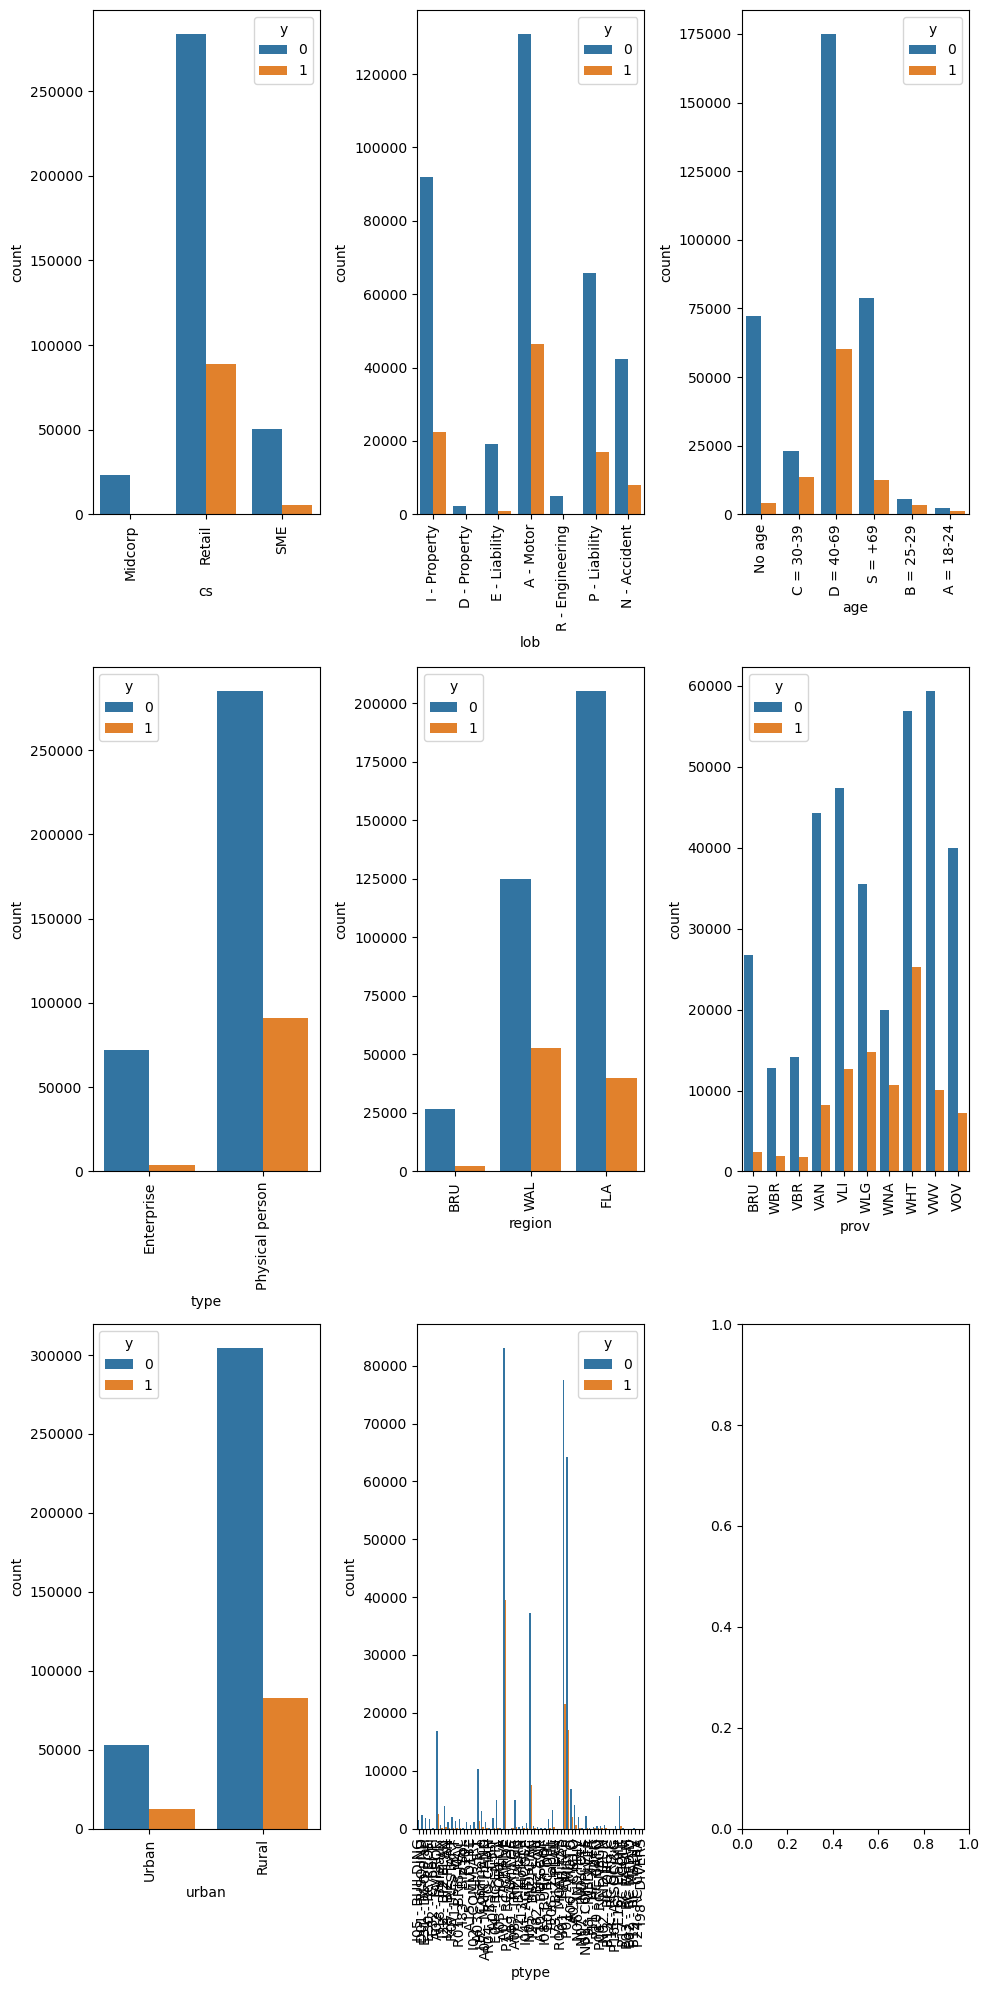

In [15]:
# Gráficas de distribución de variables categóricas
fig, axs = plt.subplots(nrows=3, ncols=3, figsize = (10, 20))
axs = axs.flatten()

for i, var in enumerate (cat):
    sns.countplot(x=var, hue=df['y'], data = df[cat], ax=axs[i])
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation = 90)
    
#Ajustar espacio entre subplots
fig.tight_layout()

#Mostrar el plot
plt.show()

In [16]:
# Codificación de variables categóricas
label_encoder = preprocessing.LabelEncoder()

for col in df[cat]:
    df[col]= label_encoder.fit_transform(df[col])

In [17]:
# Conteo de registros por clasificación para remuestreo
df.y.value_counts()

y
0    357121
1     95035
Name: count, dtype: int64

In [18]:
# Remuestreo hacía arriba de la clasificación minoritaria a 357121 registros
df_majority = df[(df['y']==0)] 
df_minority = df[(df['y']==1)]
df_minority_upsampled = resample(df_minority, 
                                 replace=True,
                                 n_samples= 357121, 
                                 random_state=0)

# Combinar la clase mayoritaria con la muestra ascendente de la clase minoritaria 
df = pd.concat([df_minority_upsampled, df_majority])

# Revisión de conteo
df.y.value_counts()

y
1    357121
0    357121
Name: count, dtype: int64

<Axes: xlabel='premium'>

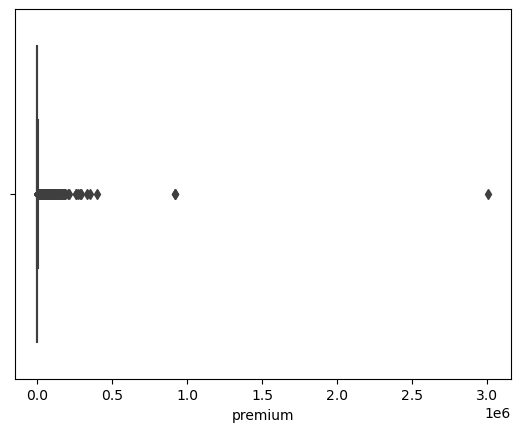

In [19]:
# Distribución de la variable numérica en los datos remuestrados
sns.boxplot(x=df.premium)

In [20]:
q1 = df.premium.quantile(0.25)
q3 = df.premium.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df_clean = df[(df.premium >= lower_bound) & (df.premium <= upper_bound)]

<Axes: xlabel='premium'>

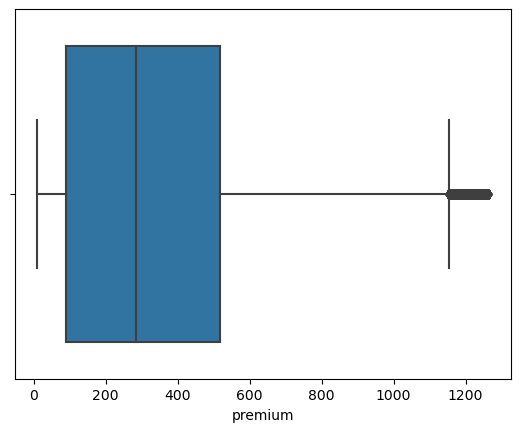

In [21]:
sns.boxplot(x=df_clean.premium)

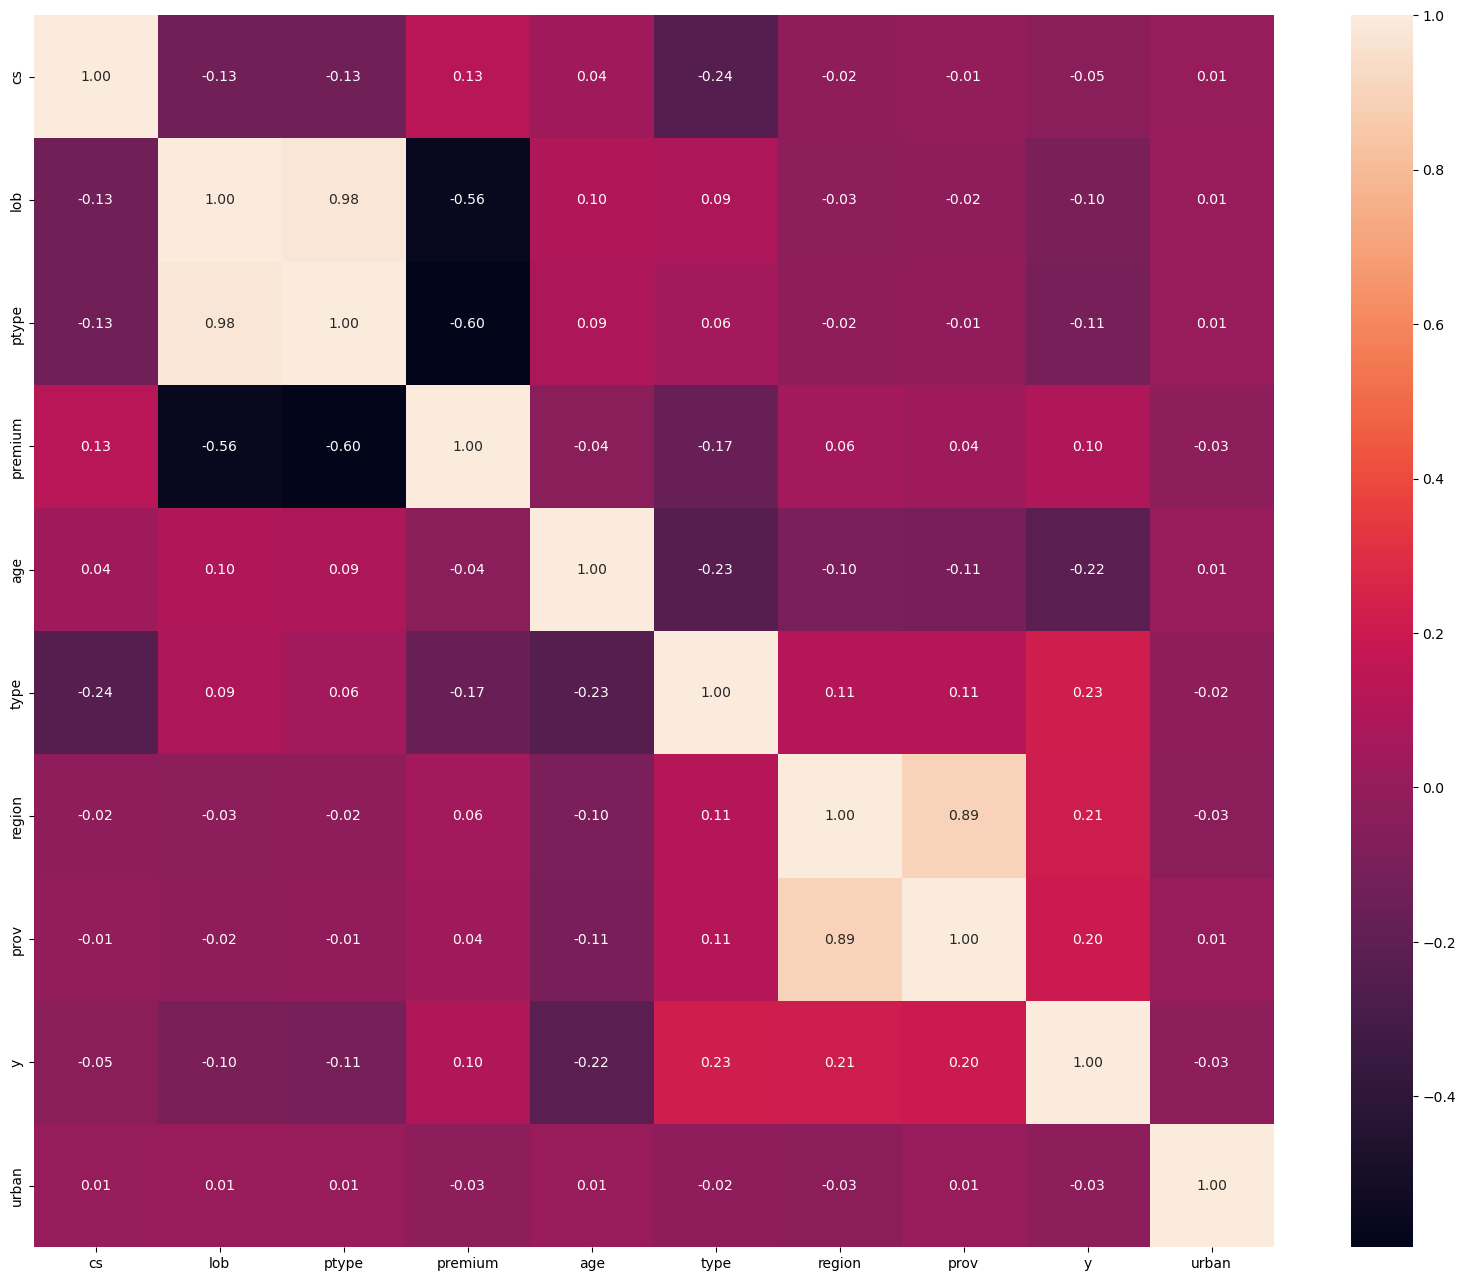

In [22]:
# Matriz de correlación de datos
corr_matrix = df_clean.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.show()

## Correlation Matrix

A heatmap is generated to identify multicollinearity between features before modeling.

**Key observations from the presentation:**
- **Strong correlations:** Product Type ↔ Line of Business · Annual Premium ↔ Product Type · Broker Province ↔ Broker Region · Broker Region ↔ Customer Region
- **Moderate correlations:** Customer Type ↔ Customer Age · Is Direct Debit ↔ Payment Frequency
- **Low correlations:** All remaining variables
- Geographic variables (region, province) cluster together as expected


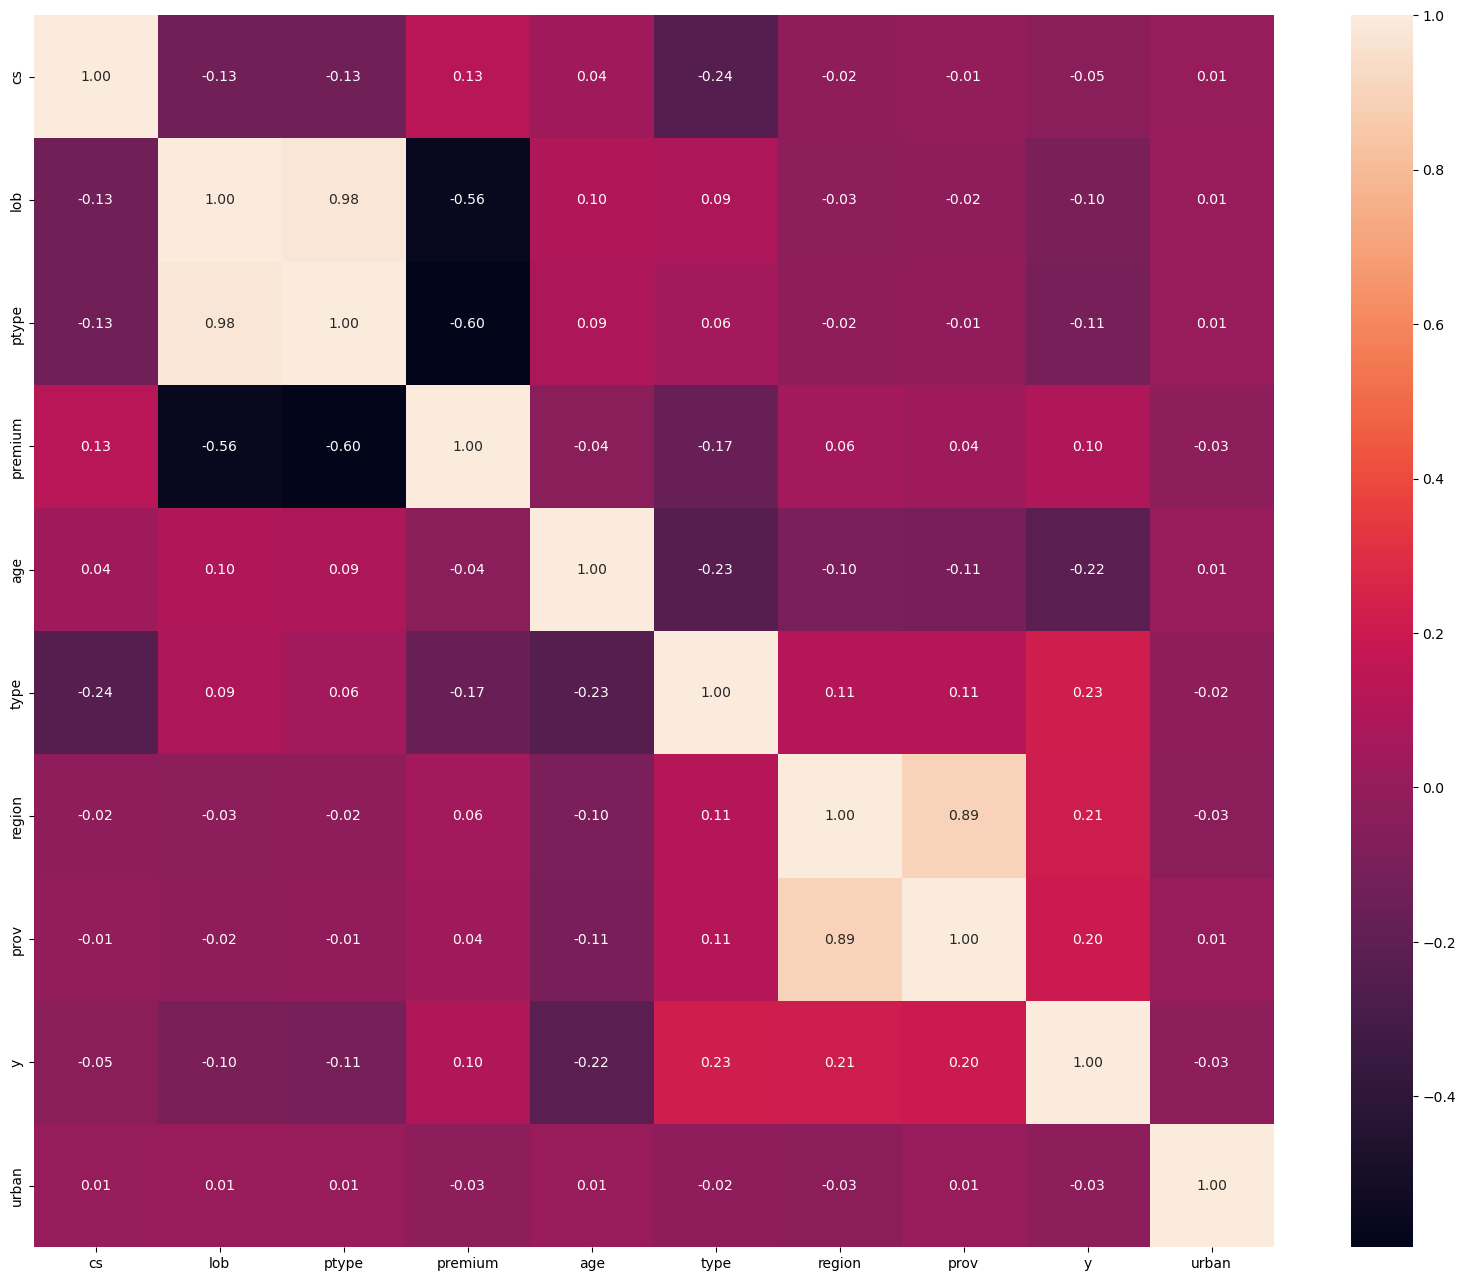

In [22]:
# Matriz de correlación de datos
corr_matrix = df_clean.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.show()

## Train / Test Split

70% training, 30% test. `random_state=0` for reproducibility.

In [23]:
X = df_clean.drop(['y'], axis=1)
y = df_clean['y']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,random_state=0)

---

## Part 1 – Models with Product Variables

The first set of models is trained on all 10 features, including `premium` (annual premium) and `ptype` (product type).


## Modelos de aprendizaje

Se evaluaron los modelos de clasificación:
- Regresión logística
- Árbol de decisiones
- Bosque aleatorio

### Logistic Regression

Baseline model. Trained with `max_iter=1,000,000` to ensure convergence on the full feature set.

**Result: F1 = 0.626 · Log Loss = 13.47**


In [26]:
model = LogisticRegression(random_state=0, max_iter= 1000000)
model.fit(X_train, y_train)
y_pred_en = model.predict(X_test)
print('Precisión en el set de Entrenamiento: {:.2f}'
     .format(model.score(X_train, y_train)))
print('Precisión en el set de Test: {:.2f}'
     .format(model.score(X_test, y_test)))

Precisión en el set de Entrenamiento: 0.65
Precisión en el set de Test: 0.64


In [27]:
print('F-1 Score : ',(f1_score(y_test, y_pred_en, average='micro')))
print('Precision Score : ',(precision_score(y_test, y_pred_en, average='micro')))
print('Recall Score : ',(recall_score(y_test, y_pred_en, average='micro')))
print('Log Loss : ', (log_loss(y_test,y_pred_en)))

F-1 Score :  0.644880599344467
Precision Score :  0.644880599344467
Recall Score :  0.644880599344467
Log Loss :  12.799800588979055


#### Confusion Matrix – Logistic Regression

<Axes: >

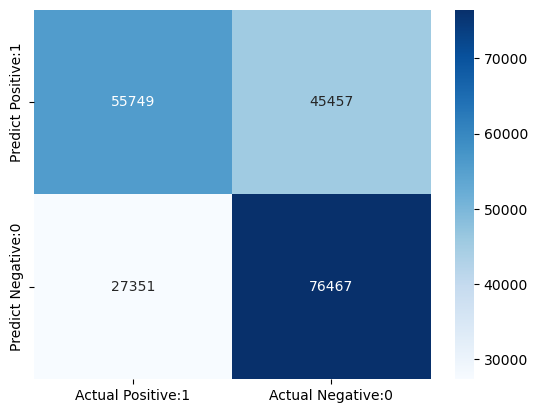

In [28]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_en)
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues')

### Decision Tree

Trained with Gini criterion and `max_depth=3` to limit overfitting while maintaining interpretability.

**Result: F1 = 0.648 · Log Loss = 12.67**


In [30]:
model = DecisionTreeClassifier(criterion= 'gini', max_depth= 3, random_state=0)
model.fit(X_train, y_train)

#Hacemos predicciones
y_pred_en = model.predict(X_test)

print('Precisión en el set de Entrenamiento: {:.2f}'
     .format(model.score(X_train, y_train)))
print('Precisión en el set de Test: {:.2f}'
     .format(model.score(X_test, y_test)))

Precisión en el set de Entrenamiento: 0.65
Precisión en el set de Test: 0.64


In [31]:
print('F-1 Score : ',(f1_score(y_test, y_pred_en, average='micro')))
print('Precision Score : ',(precision_score(y_test, y_pred_en, average='micro')))
print('Recall Score : ',(recall_score(y_test, y_pred_en, average='micro')))
print('Log Loss : ', (log_loss(y_test,y_pred_en)))

F-1 Score :  0.6436904947713439
Precision Score :  0.6436904947713439
Recall Score :  0.6436904947713439
Log Loss :  12.842696305709508


#### Confusion Matrix – Decision Tree

<Axes: >

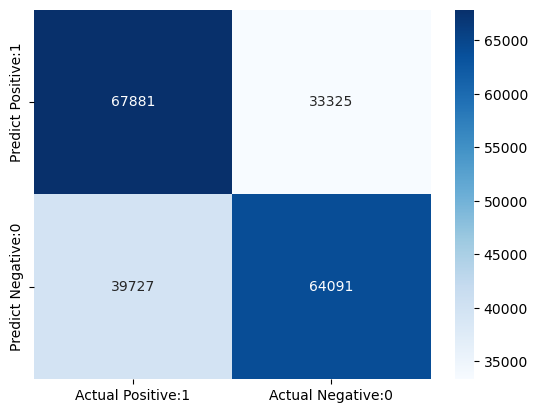

In [32]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_en)
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues')

#### Decision Tree Plot

Visual representation of the tree structure up to `max_depth=3`.

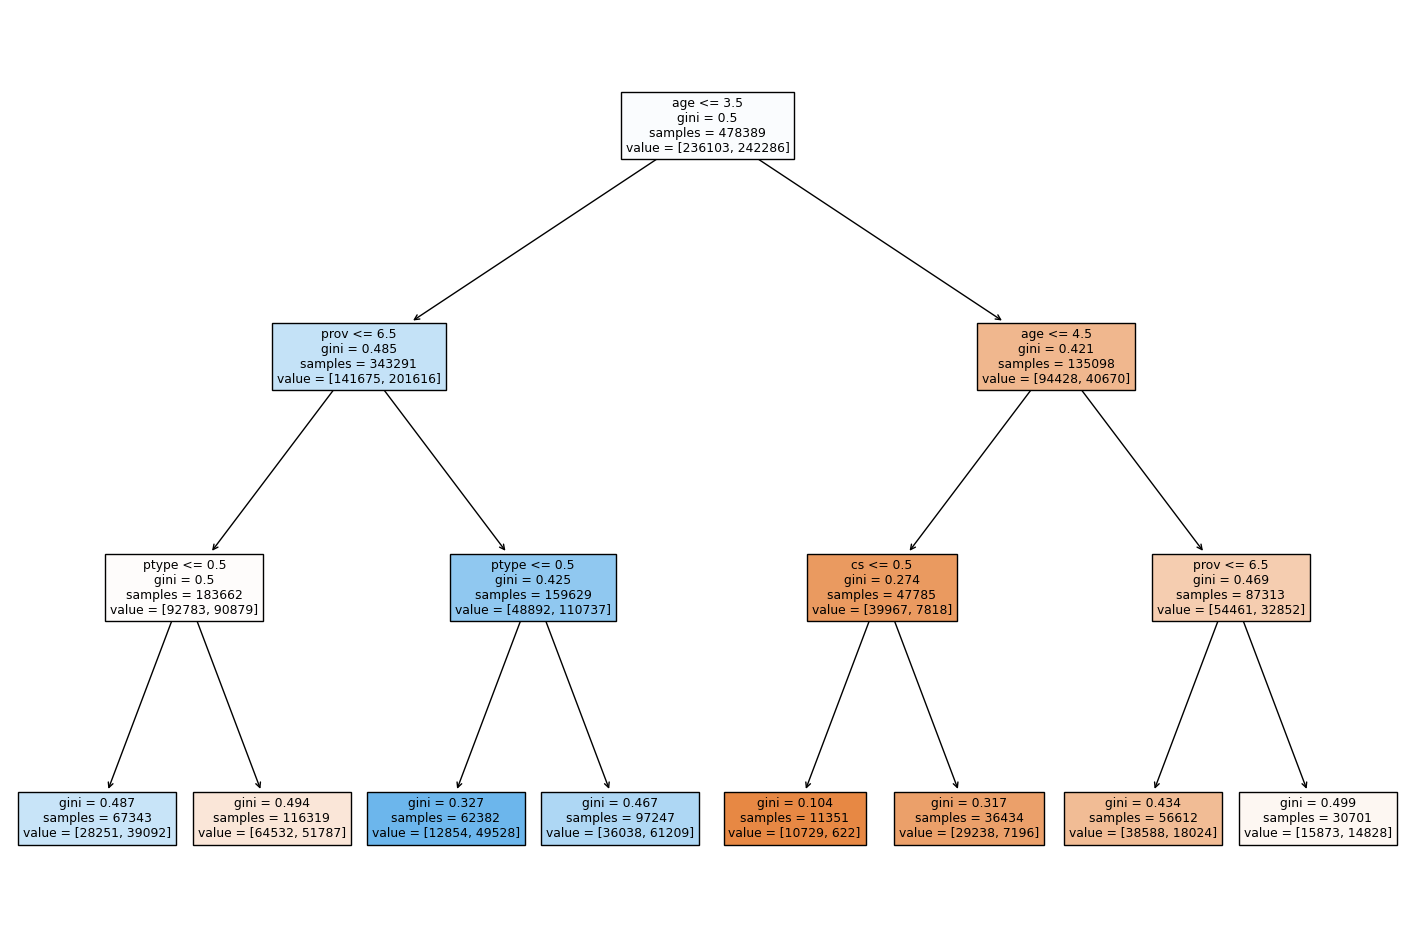

In [33]:
dt_feature_names = list(df_clean.columns)
plt.figure(figsize=(18,12))

tree.plot_tree(model.fit(X_train, y_train), filled=True, feature_names=dt_feature_names);

#### Feature Importance – Decision Tree

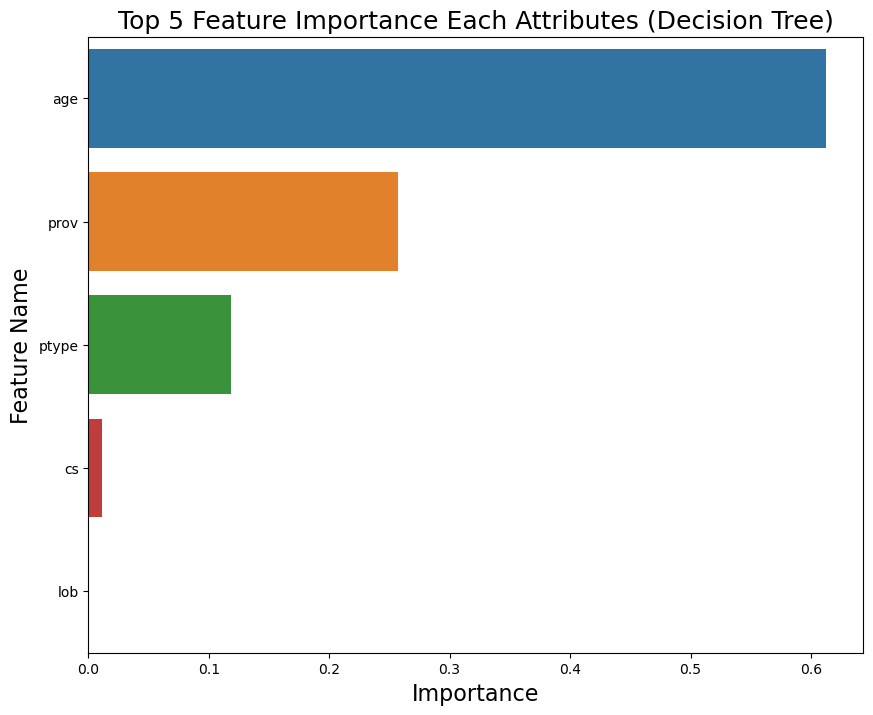

In [34]:
imp_df = pd.DataFrame({
    "Feature Name": X_train.columns,
    "Importance": model.feature_importances_
})
fi = imp_df.sort_values(by="Importance", ascending=False)

fi2 = fi.head(5)
plt.figure(figsize=(10,8))
sns.barplot(data=fi2, x='Importance', y='Feature Name')
plt.title('Top 5 Feature Importance Each Attributes (Decision Tree)', fontsize=18)
plt.xlabel ('Importance', fontsize=16)
plt.ylabel ('Feature Name', fontsize=16)
plt.show()

### Random Forest

Ensemble of 10 decision trees (`n_estimators=10`). Best performing model in Part 1.

**Result: F1 = 0.826 · Log Loss = 6.27** ← recommended model


In [36]:
model = RandomForestClassifier(n_estimators= 10, random_state=0)
model.fit(X_train, y_train)

#Hacemos predicciones
y_pred_en = model.predict(X_test)

print('Precisión en el set de Entrenamiento: {:.2f}'
     .format(model.score(X_train, y_train)))
print('Precisión en el set de Test: {:.2f}'
     .format(model.score(X_test, y_test)))

Precisión en el set de Entrenamiento: 0.92
Precisión en el set de Test: 0.81


In [37]:
print('F-1 Score : ',(f1_score(y_test, y_pred_en, average='micro')))
print('Precision Score : ',(precision_score(y_test, y_pred_en, average='micro')))
print('Recall Score : ',(recall_score(y_test, y_pred_en, average='micro')))
print('Log Loss : ', (log_loss(y_test,y_pred_en)))

F-1 Score :  0.8147094974246919
Precision Score :  0.8147094974246918
Recall Score :  0.8147094974246918
Log Loss :  6.67854665111973


#### Confusion Matrix – Random Forest

Random Forest: 80.7K true positives · 98.2K true negatives. Significantly better than Decision Tree (73.2K / 65.9K).

<Axes: >

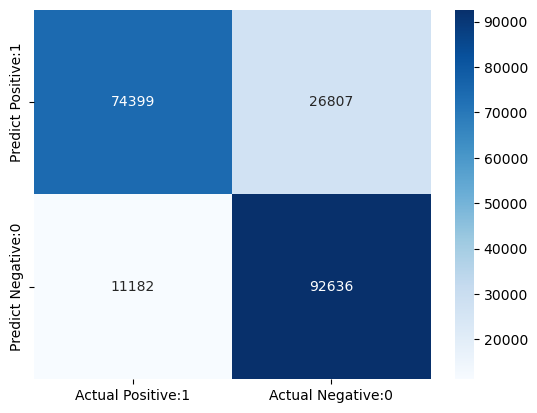

In [38]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_en)
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues')

#### Feature Importance – Random Forest

`premium` (annual premium) is the single most important feature, followed by `age`, `province`, `ptype`, and `type`. This finding is consistent across both Random Forest and Decision Tree.

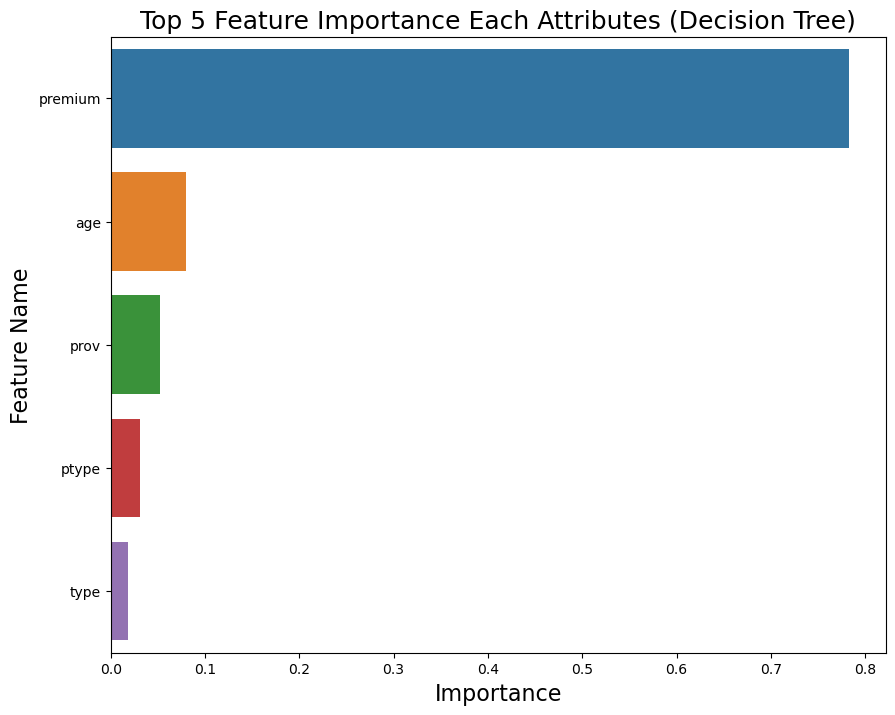

In [39]:
imp_df = pd.DataFrame({
    "Feature Name": X_train.columns,
    "Importance": model.feature_importances_
})
fi = imp_df.sort_values(by="Importance", ascending=False)

fi2 = fi.head(5)
plt.figure(figsize=(10,8))
sns.barplot(data=fi2, x='Importance', y='Feature Name')
plt.title('Top 5 Feature Importance Each Attributes (Decision Tree)', fontsize=18)
plt.xlabel ('Importance', fontsize=16)
plt.ylabel ('Feature Name', fontsize=16)
plt.show()

---

## Part 2 – Models Without Product Variables

Since `premium` dominates feature importance, a second experiment removes both `ptype` and `premium` to evaluate whether the remaining customer profile variables still carry predictive power. This answers a key business question: **can we predict direct debit propensity from customer characteristics alone, without knowing their product details?**


In [41]:
df_noproduct= df_clean.drop(['ptype', 'premium'], axis= 1)

In [82]:
X = df_noproduct.drop(['y'], axis=1)
y = df_noproduct['y']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,random_state=0)

### Decision Tree (No Product Variables)

Same configuration as Part 1 (Gini, `max_depth=3`), trained without `premium` and `ptype`.


In [84]:
model = DecisionTreeClassifier(criterion= 'gini', max_depth= 3, random_state=0)
model.fit(X_train, y_train)

#Hacemos predicciones
y_pred_en = model.predict(X_test)

print('Precisión en el set de Entrenamiento: {:.2f}'
     .format(model.score(X_train, y_train)))
print('Precisión en el set de Test: {:.2f}'
     .format(model.score(X_test, y_test)))

Precisión en el set de Entrenamiento: 0.64
Precisión en el set de Test: 0.64


In [86]:
print('F-1 Score : ',(f1_score(y_test, y_pred_en, average='micro')))
print('Precision Score : ',(precision_score(y_test, y_pred_en, average='micro')))
print('Recall Score : ',(recall_score(y_test, y_pred_en, average='micro')))
print('Log Loss : ', (log_loss(y_test,y_pred_en)))

F-1 Score :  0.6380813953488372
Precision Score :  0.6380813953488372
Recall Score :  0.6380813953488372
Log Loss :  13.044868741119432


#### Confusion Matrix – Decision Tree (No Product Variables)

<Axes: >

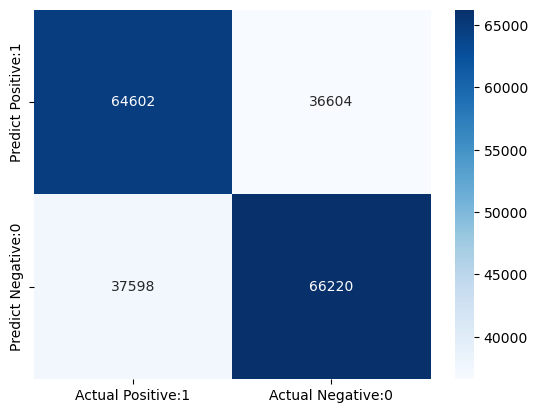

In [88]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_en)
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues')

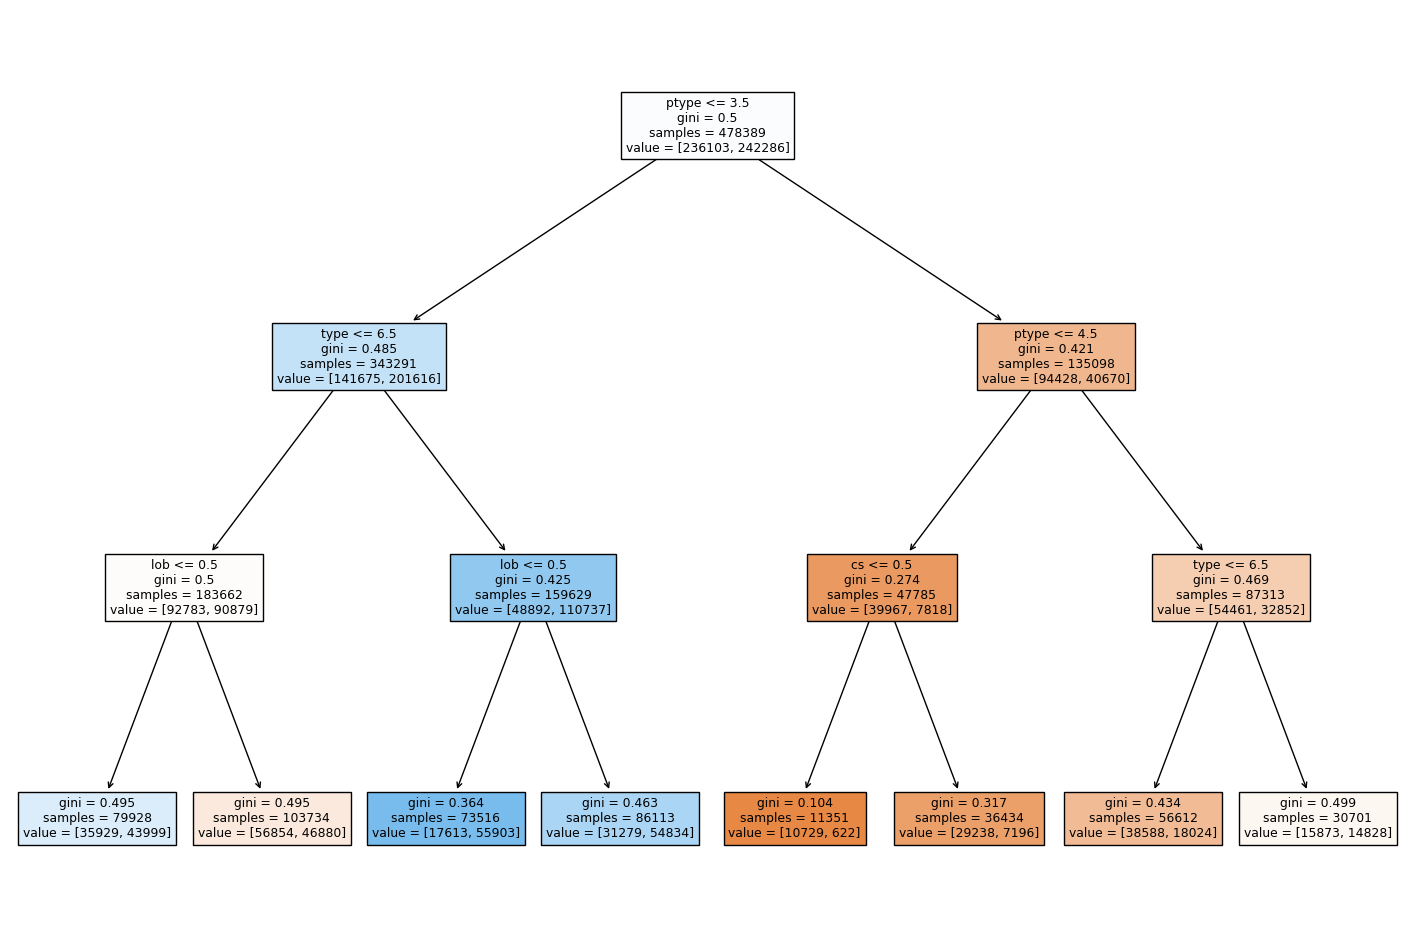

In [91]:
dt_feature_names = list(df_clean.columns)
plt.figure(figsize=(18,12))

tree.plot_tree(model.fit(X_train, y_train), filled=True, feature_names=dt_feature_names);

#### Feature Importance – Decision Tree (No Product Variables)

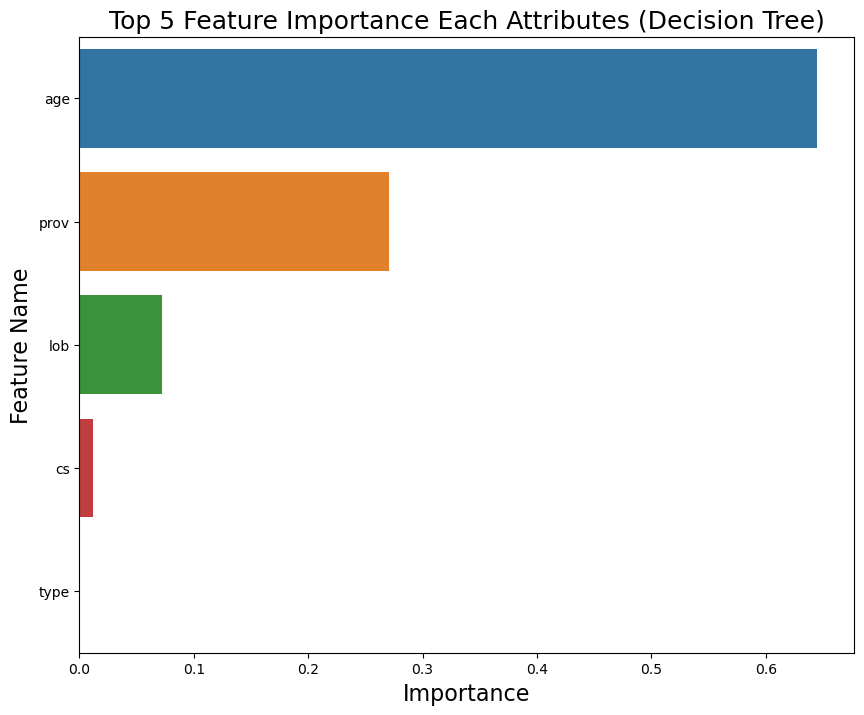

In [93]:
imp_df = pd.DataFrame({
    "Feature Name": X_train.columns,
    "Importance": model.feature_importances_
})
fi = imp_df.sort_values(by="Importance", ascending=False)

fi2 = fi.head(5)
plt.figure(figsize=(10,8))
sns.barplot(data=fi2, x='Importance', y='Feature Name')
plt.title('Top 5 Feature Importance Each Attributes (Decision Tree)', fontsize=18)
plt.xlabel ('Importance', fontsize=16)
plt.ylabel ('Feature Name', fontsize=16)
plt.show()

### Random Forest (No Product Variables)

Same configuration as Part 1 (`n_estimators=10`), trained without `premium` and `ptype`.


In [95]:
model = RandomForestClassifier(n_estimators= 10, random_state=0)
model.fit(X_train, y_train)

#Hacemos predicciones
y_pred_en = model.predict(X_test)

print('Precisión en el set de Entrenamiento: {:.2f}'
     .format(model.score(X_train, y_train)))
print('Precisión en el set de Test: {:.2f}'
     .format(model.score(X_test, y_test)))

Precisión en el set de Entrenamiento: 0.66
Precisión en el set de Test: 0.65


In [98]:
print('F-1 Score : ',(f1_score(y_test, y_pred_en, average='micro')))
print('Precision Score : ',(precision_score(y_test, y_pred_en, average='micro')))
print('Recall Score : ',(recall_score(y_test, y_pred_en, average='micro')))
print('Log Loss : ', (log_loss(y_test,y_pred_en)))

F-1 Score :  0.6547282269392851
Precision Score :  0.6547282269392851
Recall Score :  0.6547282269392851
Log Loss :  12.44485611324632


#### Confusion Matrix – Random Forest (No Product Variables)

<Axes: >

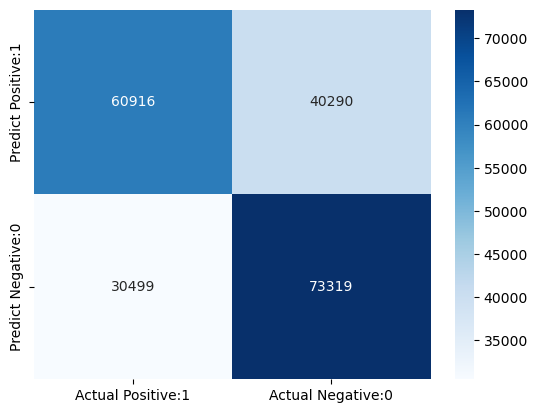

In [100]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_en)
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues')

#### Feature Importance – Random Forest (No Product Variables)

With `premium` removed, `age`, `region`, `province`, and `type` become the dominant predictors — confirming that customer demographics and geography carry independent predictive signal beyond product characteristics.

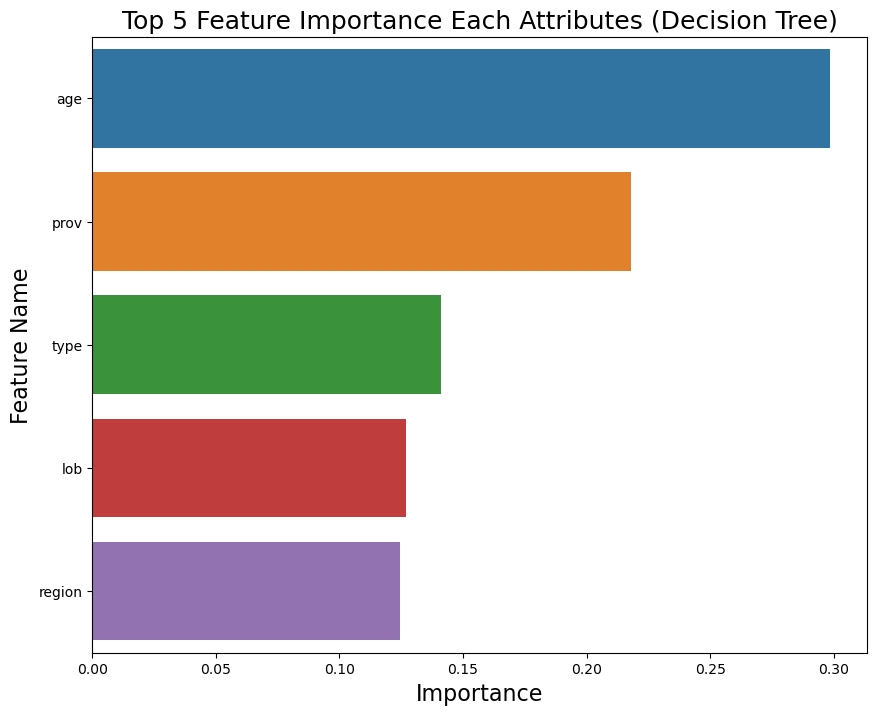

In [102]:
imp_df = pd.DataFrame({
    "Feature Name": X_train.columns,
    "Importance": model.feature_importances_
})
fi = imp_df.sort_values(by="Importance", ascending=False)

fi2 = fi.head(5)
plt.figure(figsize=(10,8))
sns.barplot(data=fi2, x='Importance', y='Feature Name')
plt.title('Top 5 Feature Importance Each Attributes (Decision Tree)', fontsize=18)
plt.xlabel ('Importance', fontsize=16)
plt.ylabel ('Feature Name', fontsize=16)
plt.show()

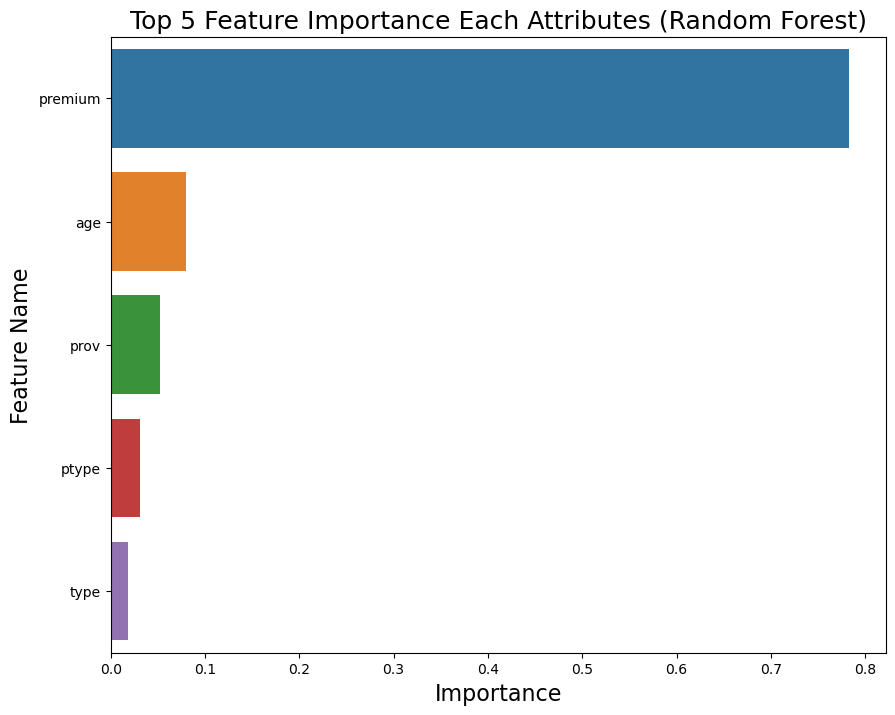

In [42]:
imp_df = pd.DataFrame({
    "Feature Name": X_train.columns,
    "Importance": model.feature_importances_
})
fi = imp_df.sort_values(by="Importance", ascending=False)

fi2 = fi.head(5)
plt.figure(figsize=(10,8))
sns.barplot(data=fi2, x='Importance', y='Feature Name')
plt.title('Top 5 Feature Importance Each Attributes (Random Forest)', fontsize=18)
plt.xlabel ('Importance', fontsize=16)
plt.ylabel ('Feature Name', fontsize=16)
plt.show()

---

## Conclusions & Key Findings

### Model Comparison

| Model | F1 Score | Log Loss |
|---|---|---|
| **Random Forest (with product vars)** | **0.826** | **6.27** |
| Decision Tree (with product vars) | 0.648 | 12.67 |
| Logistic Regression | 0.626 | 13.47 |

**Recommended model: Random Forest** — highest F1, lowest log loss, no overfitting.

### Key Findings

1. **Annual premium is the strongest predictor** of direct debit adoption across all models — policyholders with higher premiums are significantly more likely to use direct debit, possibly because the financial benefit (avoiding late fees, automated cash flow) is more tangible at higher payment amounts.

2. **Customer demographics matter independently** — even without product variables, `age`, `region`, `province`, and `customer_type` retain predictive power, enabling propensity scoring from CRM data alone.

3. **EDA insights on high-propensity profiles:** Retail segment · Physical person · Motor insurance · Age 40–69 · Premium products · FLA broker region · VWV broker province · Rural customer location.

### Business Impact

- **Better working capital management** — predictable cash inflow from automated payments
- **Reduced administrative costs** — fewer manual payment reminders and follow-ups
- **Targeted marketing** — model outputs can score the existing portfolio and prioritize outreach to highest-propensity policyholders, directly addressing the 21% → 65% gap
